In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from keras.models import load_model
from keras.preprocessing import image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [24]:
# set the input image size for the ResNet50 model
img_width, img_height = 224, 224

In [25]:
# set the directories for the training,validation,testing data
train_dir = 'Train_Tomatoes'
val_dir = 'Validate_Tomatoes'
test_dir = 'Test_Tomatoes'

In [26]:
# set the batch size for training and validation data
batch_size = 15

In [27]:
# create a data generator with data augmentation for the training data
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [28]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 144 images belonging to 3 classes.
Found 84 images belonging to 3 classes.
Found 42 images belonging to 3 classes.


In [29]:
# load the ResNet50 model pretrained on ImageNet without the classification layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

In [30]:
# Freeze all layers in the base model
for layer in base_model.layers:
    layer.trainable = False

In [31]:
# Add custom classification head
x = layers.Flatten()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(3, activation='softmax')(x)

In [32]:
# Compile the model
model = keras.models.Model(inputs=base_model.input, outputs=output)
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

In [33]:
# Train the model
epochs = 20
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)


Epoch 1/20
10/10 [==============================] - 27s 2s/step - loss: 1.2799 - accuracy: 0.4236 - val_loss: 0.7143 - val_accuracy: 0.7262
Epoch 2/20
10/10 [==============================] - 18s 2s/step - loss: 0.8453 - accuracy: 0.6736 - val_loss: 0.5571 - val_accuracy: 0.7857
Epoch 3/20
10/10 [==============================] - 19s 2s/step - loss: 0.4739 - accuracy: 0.8194 - val_loss: 0.4582 - val_accuracy: 0.7976
Epoch 4/20
10/10 [==============================] - 19s 2s/step - loss: 0.4655 - accuracy: 0.8333 - val_loss: 0.3805 - val_accuracy: 0.8214
Epoch 5/20
10/10 [==============================] - 19s 2s/step - loss: 0.3124 - accuracy: 0.8472 - val_loss: 0.3198 - val_accuracy: 0.8333
Epoch 6/20
10/10 [==============================] - 18s 2s/step - loss: 0.1569 - accuracy: 0.9375 - val_loss: 0.2665 - val_accuracy: 0.9048
Epoch 7/20
10/10 [==============================] - 18s 2s/step - loss: 0.2714 - accuracy: 0.9028 - val_loss: 0.2407 - val_accuracy: 0.9167
Epoch 8/20
10/10 [==

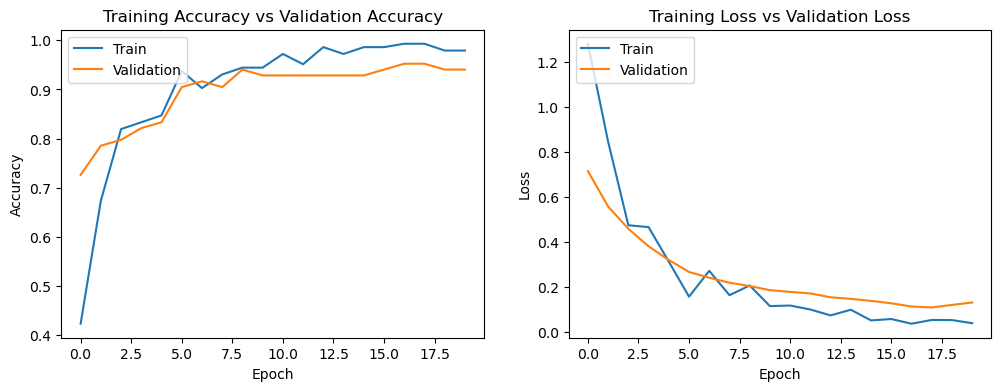

In [34]:
import matplotlib.pyplot as plt

fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
fig.set_size_inches(12,4)

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Training Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Training Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

plt.show()

3/3 [==============================] - 5s 807ms/step


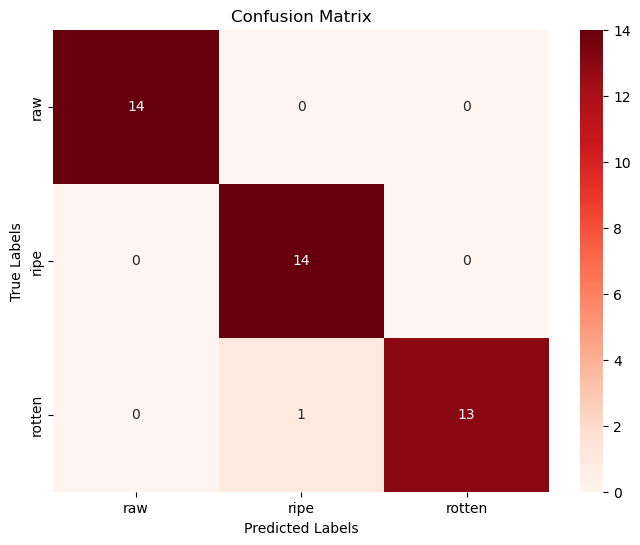

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.93      0.96        14

    accuracy                           0.98        42
   macro avg       0.98      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42

F1 score: 0.9761600681140912


In [35]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Make predictions on the test data
test_preds = model.predict(test_generator)

# Convert the predictions to class labels
test_pred_labels = np.argmax(test_preds, axis=1)

# Get the true class labels for the test data
test_true_labels = test_generator.classes

# Calculate precision, recall, and F1 score
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(test_true_labels, test_pred_labels)

# Define class labels
class_labels = ["raw", "ripe", "rotten"]

# Plot confusion matrix with color
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Reds", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# Print classification report
print(classification_report(test_true_labels, test_pred_labels))

print('F1 score:', f1_score(test_true_labels, test_pred_labels, average='weighted'))

In [36]:
# Save the model
model.save('resnet_model.h5')